# 13장 실습 ④ — 이상 탐지가 **되는** 경우

**PyTorch 판**

실습 ③에서는 AUC가 0.5 근처였습니다. 여기서는 0.99입니다.
**무엇이 다른지**가 이 절의 요지입니다.

## 13.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '-', 'tensorflow': '-', 'torch': '2.14.0', 'keras_backend': '-'}


## 13.1 데이터 — 정답을 쓰지 않습니다

이 장에서 처음으로 `y` 를 쓰지 않습니다.

In [3]:
# MNIST. **정답(y)을 쓰지 않습니다.** 입력이 곧 정답입니다.
s = data.mnist()
x_train = s.x_train.reshape(len(s.x_train), -1)      # (N, 784)
x_test = s.x_test.reshape(len(s.x_test), -1)
print(f"학습 {x_train.shape}, 시험 {x_test.shape}")
print()
print("★ y_train 을 한 번도 쓰지 않습니다. 이것이 비지도 학습입니다.")

def show(rows, titles, n=8):
    """여러 줄의 28x28 영상을 나란히 그린다."""
    fig, axes = plt.subplots(len(rows), n, figsize=(1.15 * n, 1.25 * len(rows)))
    axes = np.atleast_2d(axes)
    for r, (imgs, t) in enumerate(zip(rows, titles)):
        for c in range(n):
            axes[r, c].imshow(imgs[c].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
            axes[r, c].axis("off")
        axes[r, 0].set_ylabel(t)
        axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    plt.tight_layout(); plt.show()

학습 (54000, 784), 시험 (10000, 784)

★ y_train 을 한 번도 쓰지 않습니다. 이것이 비지도 학습입니다.


## 13.3 모델 정의 — 여기만 판마다 다릅니다

인코더로 줄이고 디코더로 되살립니다. **가운데가 좁은 것**이 전부입니다.

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"

class AutoEncoder(nn.Module):
    """인코더로 줄이고 디코더로 되살린다.

    **가운데가 좁은 것**이 전부입니다. 그 좁은 곳을 잠재 공간이라 부릅니다.
    """
    def __init__(self, latent, linear=False):
        super().__init__()
        act = nn.Identity if linear else nn.ReLU
        self.encoder = nn.Sequential(
            nn.Linear(784, 128), act(), nn.Linear(128, latent), act())
        self.decoder = nn.Sequential(
            nn.Linear(latent, 128), act(), nn.Linear(128, 784),
            nn.Identity() if linear else nn.Sigmoid())

    def forward(self, x):
        return self.decoder(self.encoder(x))

def train_ae(latent, xa, xb, y_train=None, y_test=None,
             linear=False, seed=42, epochs=15):
    """(시험 복원 MSE, 모델) 을 돌려준다."""
    dlbook.set_seed(seed)
    model = AutoEncoder(latent, linear).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    tgt = xa if y_train is None else y_train
    dl = DataLoader(TensorDataset(torch.tensor(xa, dtype=torch.float32),
                                  torch.tensor(tgt, dtype=torch.float32)),
                    batch_size=256, shuffle=True)
    loss_fn = nn.MSELoss()
    for _ in range(dlbook.smoke.epochs(epochs)):
        model.train()
        for xx, yy in dl:
            xx, yy = xx.to(device), yy.to(device)
            opt.zero_grad(); loss_fn(model(xx), yy).backward(); opt.step()
    target = xb if y_test is None else y_test
    return float(np.mean((reconstruct(model, xb) - target) ** 2)), model

def reconstruct(model, X):
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X, dtype=torch.float32).to(device))
    return out.cpu().numpy()

def encode(model, X):
    model.eval()
    with torch.no_grad():
        out = model.encoder(torch.tensor(X, dtype=torch.float32).to(device))
    return out.cpu().numpy()

## 13.1 이상 탐지 — 분포가 아예 다른 것

숫자로 학습하고 **옷 사진**을 보여 줍니다.

In [5]:
def recon_error(model, X):
    return np.mean((reconstruct(model, X) - X) ** 2, axis=1)

def auc(score, label):
    """ROC 곡선 아래 면적. 순위만 쓰므로 임계값을 안 정해도 된다."""
    order = np.argsort(score); r = np.empty(len(score))
    r[order] = np.arange(1, len(score) + 1)
    n1 = int(label.sum()); n0 = len(label) - n1
    return float((r[label == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))

잠재             숫자 오차        옷 오차      배수       AUC
--------------------------------------------------


8            0.02975     0.11263    3.8배     0.935
ch13_anomaly_fashion_auc_8 = 0.9351


32           0.01173     0.11183    9.5배     0.992
ch13_anomaly_fashion_auc_32 = 0.9919


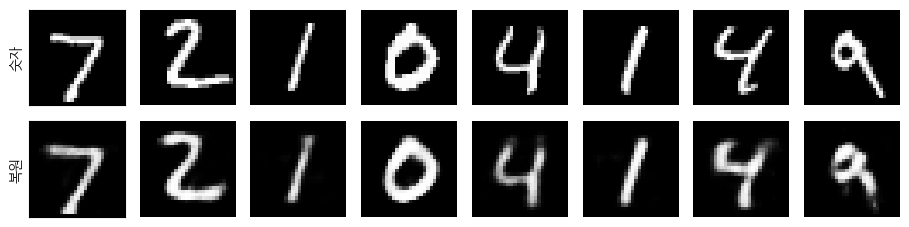

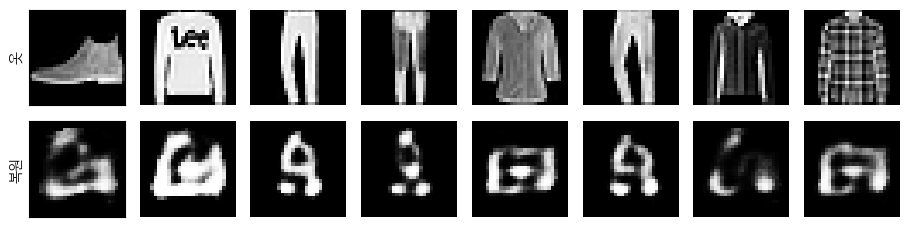


★ **이번에는 잘 됩니다.** AUC 0.99.
→ 옷 사진은 숫자로 배운 부품으로 그려지지 않습니다. 오차가 10배입니다.


In [6]:
# 분포가 아예 다른 것. 숫자로 배우고 옷 사진을 보여 준다.
f = data.fashion_mnist()
x_fashion = f.x_test.reshape(len(f.x_test), -1)

print(f"{'잠재':<8}{'숫자 오차':>12}{'옷 오차':>12}{'배수':>8}{'AUC':>10}")
print("-" * 50)
for L in ([8] if dlbook.smoke.is_smoke() else [8, 32]):
    _, m = train_ae(L, x_train, x_test)
    em, ef = recon_error(m, x_test), recon_error(m, x_fashion)
    lab = np.concatenate([np.zeros(len(em)), np.ones(len(ef))]).astype(int)
    a = auc(np.concatenate([em, ef]), lab)
    print(f"{L:<8}{em.mean():>12.5f}{ef.mean():>12.5f}"
          f"{ef.mean() / em.mean():>7.1f}배{a:>10.3f}")
    dlbook.record(f"ch13_anomaly_fashion_auc_{L}", a)

show([x_test[:8], reconstruct(m, x_test[:8])], ["숫자", "복원"])
show([x_fashion[:8], reconstruct(m, x_fashion[:8])], ["옷", "복원"])

print()
print("★ **이번에는 잘 됩니다.** AUC 0.99.")
print("→ 옷 사진은 숫자로 배운 부품으로 그려지지 않습니다. 오차가 10배입니다.")

## 정리

| 실험 | 무엇을 찾나 | AUC |
|---|---|:--:|
| ③ 0~8로 학습 | 숫자 '9' | **0.51~0.60** |
| ④ 숫자로 학습 | 옷 사진 | **0.96~0.99** |

- **오토인코더 이상 탐지는 「얼마나 다른가」에 달려 있습니다.**
- 분포가 아예 다르면 잘 잡습니다(②).
- **같은 분포 안의 새 종류는 못 잡습니다**(①). 0~8을 배우며 익힌 획과
  곡선으로 9도 그려 버리기 때문입니다.
- 그러니 *"오토인코더로 불량품을 찾는다"* 는 계획은 **불량이 정상과
  얼마나 다른지**를 먼저 따져야 합니다.

### 연습

1. 실험 ①에서 **다른 숫자**(0, 1, 8)를 이상으로 두면 AUC가 달라집니까.
   어느 숫자가 가장 잘 잡힙니까. **왜입니까.**
2. 복원 오차 대신 **잠재 벡터까지의 거리**로 점수를 매기면 나아집니까.
3. 실험 ②에서 옷 사진 대신 **뒤집은 숫자**를 넣으면 어떻게 됩니까.
4. (논술) 공장 불량 검출에 이 방법을 쓰려 한다. 실험 ①과 ② 중 어느 쪽에
   가까운 상황인지 어떻게 판단하겠는가.